In [1]:
using Pkg
Pkg.activate(".")

  Activating project at `~/code/compositional`


In [2]:
using DataFrames, CairoMakie
using FHist, Statistics, SpecialFunctions
using LsqFit

In [3]:
include("./Data_Input.jl")
using .DataImport

include("./Distributions.jl")
using .MakeDistributions

In [4]:
sep_data = DataImport.GetCrossSecData("./Data/crosssecdata.RData"; min_samples=5e1, min_counts=1, min_nreads=1e4);

 `sep_data` contains 14 possible environments: `SEAWATER`, `ORAL`, `GUT`, `VAGINAL`, `SOIL`, `ORALCAVITY`, `FECES`, `SKIN`, `GLACIER`, `AQUA1`, `RIVER`, `LAKE`, `AQUA2`, `SLUDGE`.\
 Then each environment consists of a dataset stored in a dataFrame with the following features:\
 **project_id**: identifies projects\
**sample_id**: identifies samples (communities) gathered within the same environment\
**run_id**: identifies the machine run to identify species in a sample. Multiple runs are possible within the same sample\
**otu_id**: identifies species\
**count**: number of species with specific otu_id observed in a single run\
**nreads**: total number of species observed in a single run

In [5]:
df = copy(sep_data["GUT"])
select!(df, Not([:project_id, :sample_id]))
first(df, 5)

Row,otu_id,count,run_id,nreads
,Int32,Float64,String,Float64
1,198192,3.0,SRR1952459,35839.0
2,1036749,1.0,SRR1952459,35839.0
3,198190,100.0,SRR1952459,35839.0
4,543291,2.0,SRR1952459,35839.0
5,684238,1.0,SRR1952459,35839.0


### Covariance Matrix

In [243]:
occ = 0.1
freqs = MakeDistributions.get_frequencies(df, occ=occ)
stats = MakeDistributions.get_statistic(df, occ=occ, cov=true)
S = size(freqs, 2);

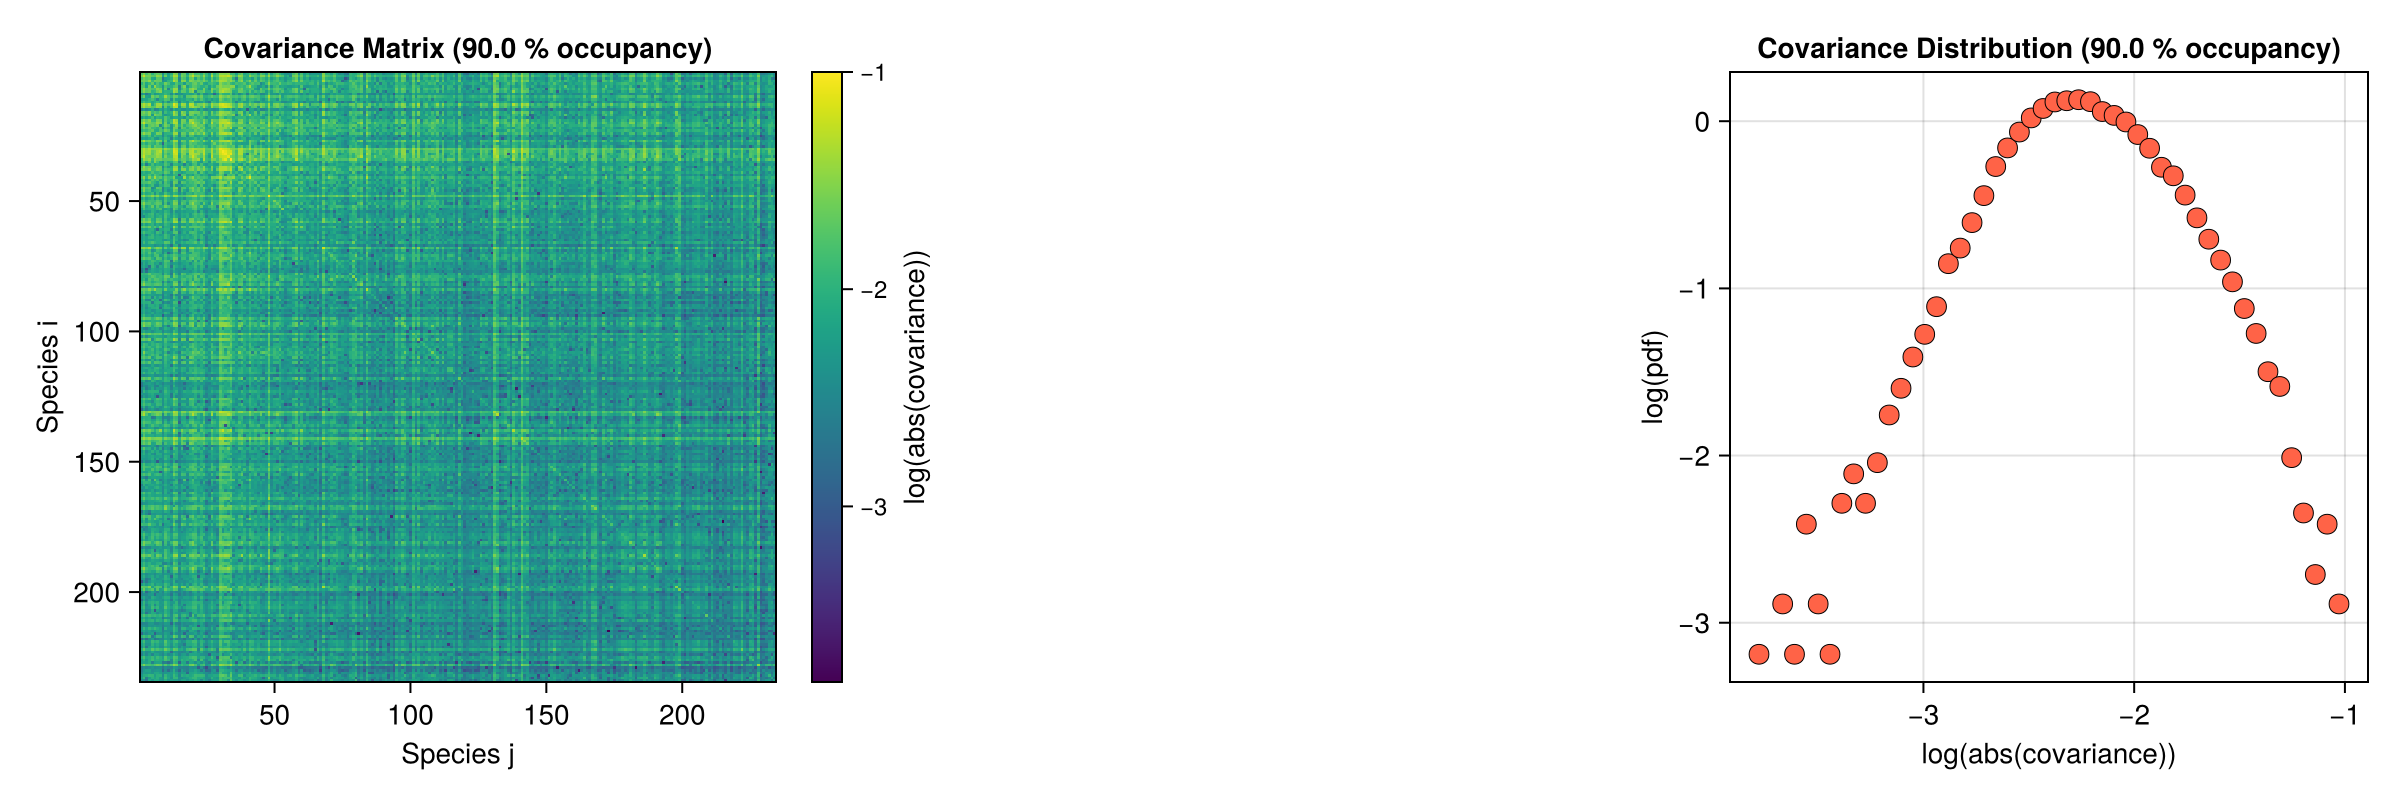

In [245]:
fig = Figure(size = (1200, 400))

# Heatmap
ax = Axis(fig[1, 1];
    title = "Covariance Matrix ($(round((1-occ)*100, digits=2)) % occupancy)",
    xlabel = "Species j",
    ylabel = "Species i",
    yreversed  = true)

mat = abs.(stats[3])
mat = log10.(mat)
mat ./= abs.(maximum(mat))
hm = heatmap!(
    ax,
    mat;
    colormap   = :viridis,
    colorrange = extrema(mat)
)

cb = Colorbar(fig[1, 2], hm;
    label         = "log(abs(covariance))",
    width         = 15,
    labelsize     = 14,
    ticklabelsize = 12
)

# Histogram
vals = [mat[i, j] for i in 1:S for j in 1:i]

bmin = minimum(vals)
bmax = maximum(vals)
Δb = (bmax - bmin) / 50
fh = FHist.Hist1D(vals, binedges=bmin:Δb:bmax)

centers = bincenters(fh)
norm_counts = bincounts(fh) ./ (integral(fh) * Δb)

# Filter non-zero counts
valid = norm_counts .> 0.0
yy = log10.(norm_counts[valid])
centers = centers[valid]

ax = Axis(fig[1, 4];
    title = "Covariance Distribution ($(round((1-occ)*100, digits=2)) % occupancy)",
    xlabel = "log(abs(covariance))",
    ylabel = "log(pdf)",)

sc = scatter!(ax, centers, yy;
         color = :tomato,
         markersize = 14,
         strokewidth = 0.5,
         strokecolor = :black)

fig


### Taylor

In [230]:
occ = 0.95
freqs = MakeDistributions.get_frequencies(df, occ=occ)
stats = MakeDistributions.get_statistic(df, occ=occ)
S = size(freqs, 2);

In [233]:
v = stats[2][stats[2] .> 0]
m = stats[1][stats[2] .> 0]

log_mean = vec(log.(m))
log_var = vec(log.(v))

# Bin x-axis (means) and aggregate y-axis (variances)
bmin = minimum(log_mean)
bmax = maximum(log_mean)
nbins = 20
Δb = (bmax - bmin) / nbins
binedges = bmin:Δb:bmax
centers = 0.5 .* (binedges[2:end] .+ binedges[1:end-1])

yy = [mean(log_var[(log_mean .>= binedges[i]) .& (log_mean .< binedges[i+1])]) for i in 1:length(binedges)-1]
centers = centers[isfinite.(yy)]
yy = yy[isfinite.(yy)]

# Fit linear model y = cx + log(b)
func(x, p) = p[1] .* x .+ p[2]
p0 = [2.0, 0.0]
fit = curve_fit(func, centers, yy, p0)
p_fit = fit.param

c = p_fit[1]
b = exp(p_fit[2])

println("c = $c \t b = $b")

c = 1.8447409026850987 	 b = 1.089443077706584


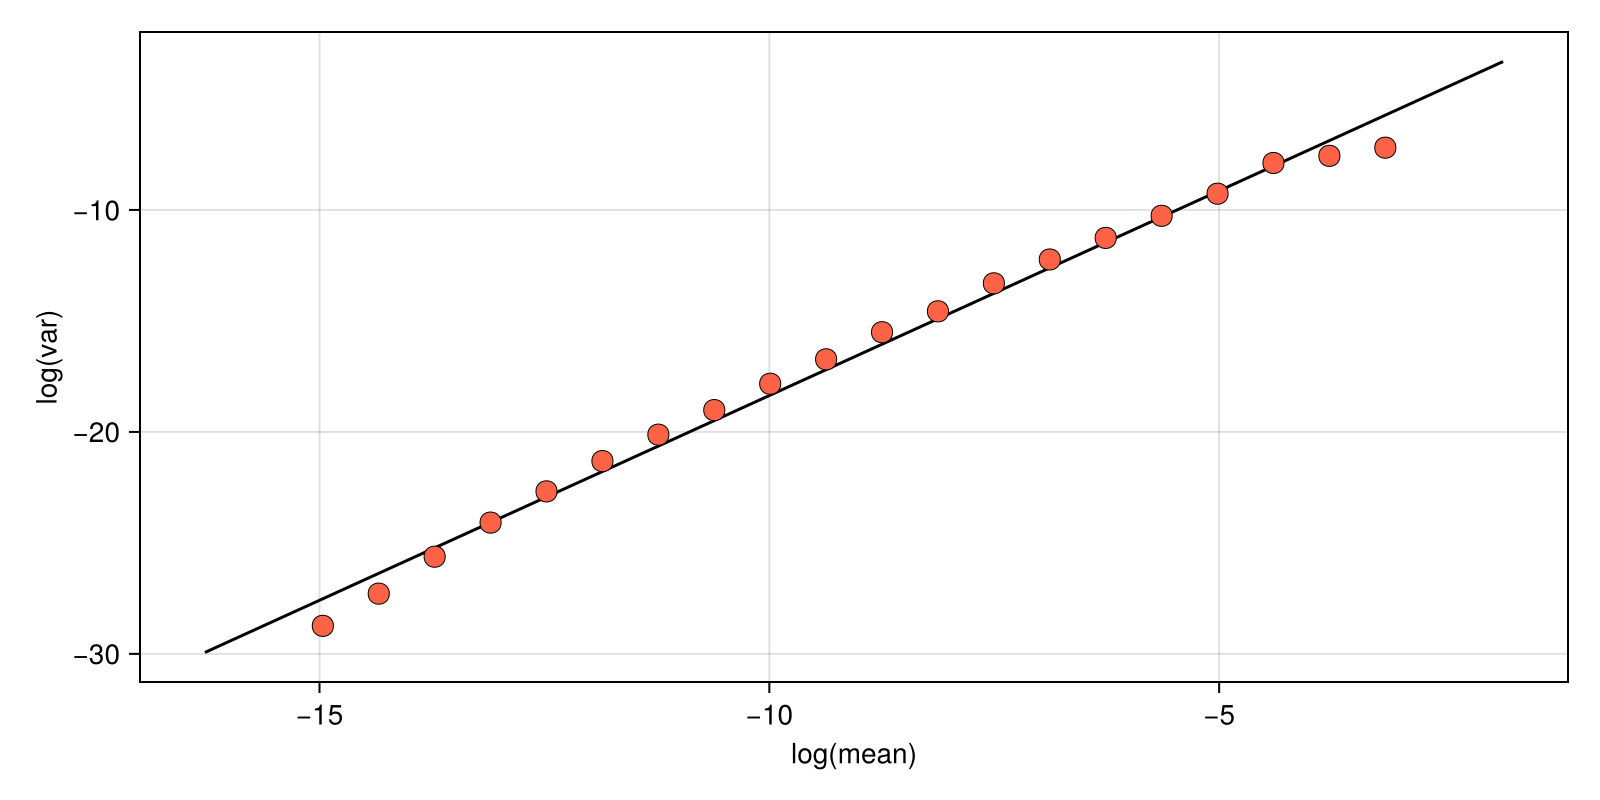

In [234]:
fig = Figure(size=(800,400))
ax = Axis(fig[1,1];
        xlabel = "log(mean)",
        ylabel="log(var)")

xrange = bmin-1:0.01:bmax+1
ln = lines!(ax, xrange, func(xrange, p_fit), color=:black)

sc = scatter!(ax, centers, yy,
             color = :tomato,
             markersize=15,
             strokewidth = 0.5,
             strokecolor = :black)

fig

### AFD

In [238]:
occ = 0.01
freqs = MakeDistributions.get_frequencies(df, occ=occ)
stats = MakeDistributions.get_statistic(df, occ=occ)
S = size(freqs, 2);

In [239]:
log_non_zero_data = [log.(x[x .> 0.0]) for x in eachcol(freqs)]
m = [mean(x) for x in log_non_zero_data]
s = [std(x) for x in log_non_zero_data]
log_non_zero_data = [(x .- m[i]) ./ s[i] for (i,x) in enumerate(log_non_zero_data)]
log_data = vcat(log_non_zero_data...)

# Compute normalized and recentered Histogram
bmin = round(minimum(log_data))
bmax = round(maximum(log_data))
Δb = (bmax - bmin) / 30
fh = FHist.Hist1D(log_data, binedges=bmin:Δb:bmax)

centers = bincenters(fh)
norm_counts = bincounts(fh) ./ (integral(fh) * Δb)

# Filter non-zero counts
valid = norm_counts .> 0.0
yy = 10 .^ log.(norm_counts[valid])
centers = centers[valid];

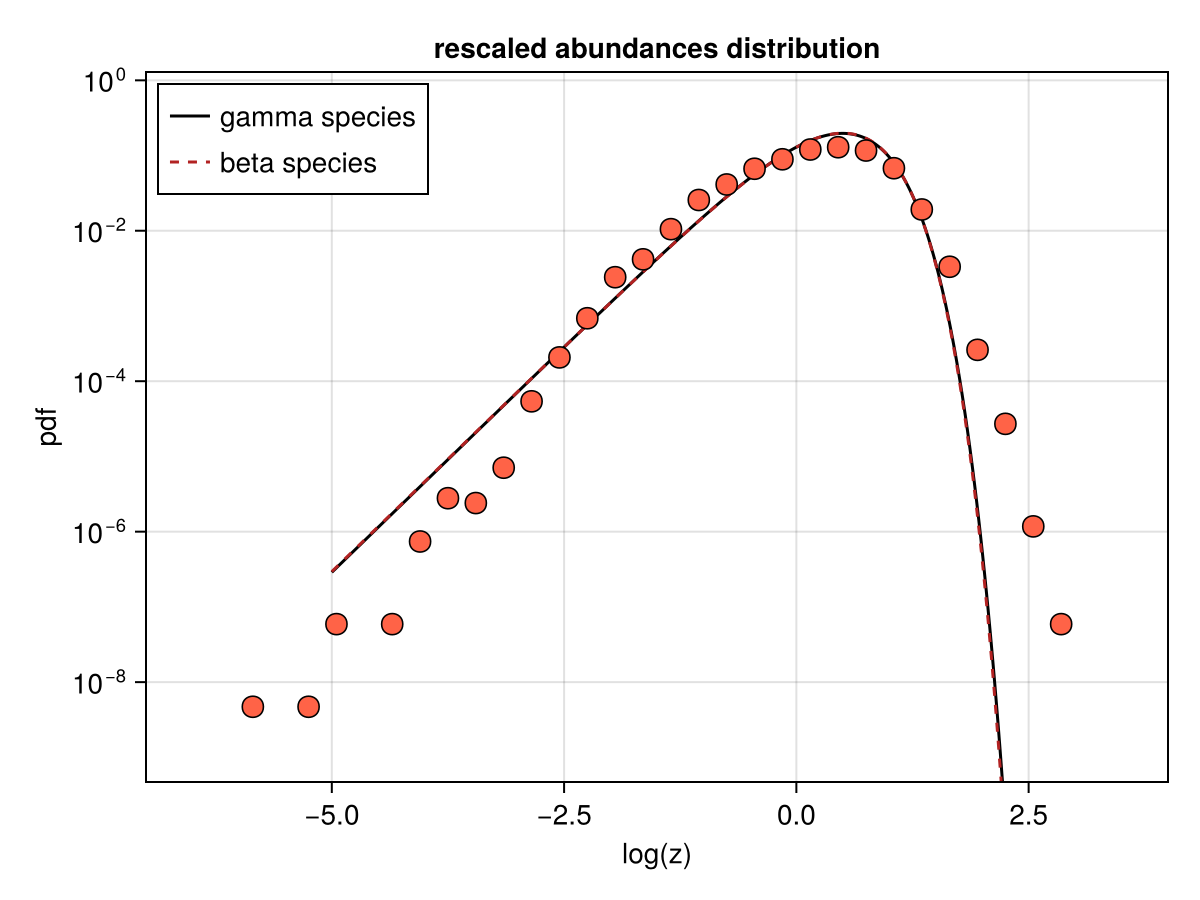

In [240]:
function lrg(z, α)
    return α*sqrt(trigamma(α)) .* z .+ α*digamma(α) .- exp.(z .* sqrt(trigamma(α)) .+ digamma(α)) .+ 0.5*log(trigamma(α)) .- loggamma(α)
end

function lrb(z, α, β)
    m = digamma(α) - digamma(α + β)
    s = sqrt(trigamma(α) - trigamma(α + β))
    c = loggamma(α + β) - loggamma(α) - loggamma(β)
    return c .+ α .* (z .* s .+ m) .+ (β - 1) .* log.(1 .- exp.(z .* s .+ m)) .+ log(s)
end

# Gamma params
α = stats[1] .^ 2 ./ stats[2]
α = mean(α)

# Beta params
γ = stats[1] ./ stats[2] .* (stats[1] .- stats[1] .^2 .- stats[2])
δ = γ .* (1 .- stats[1]) ./ stats[1]
γ = mean(γ)
δ = mean(δ)

# Plot
fig = Figure(figsize=(600,400))
ax  = Axis(fig[1, 1]; yscale=log10, limits=((bmin-1, bmax+1), (minimum(yy) / 10, maximum(yy) * 10)),
           xlabel = "log(z)", ylabel = "pdf", 
           title = "rescaled abundances distribution")

zrange = -5:0.01:3
gl = lines!(ax, zrange, 10 .^ lrg(zrange, α), color=:black, linewidth=1.5, label="gamma species")
bl = lines!(ax, zrange, 10 .^ lrb(zrange, γ, δ), color=:firebrick, linestyle=:dash, linewidth=1.5, label="beta species")

sc = scatter!(ax, centers, yy, markersize=15,
            color = :tomato,
            strokewidth = 0.8,
            strokecolor = :black)

axislegend(ax; position = :lt)

fig

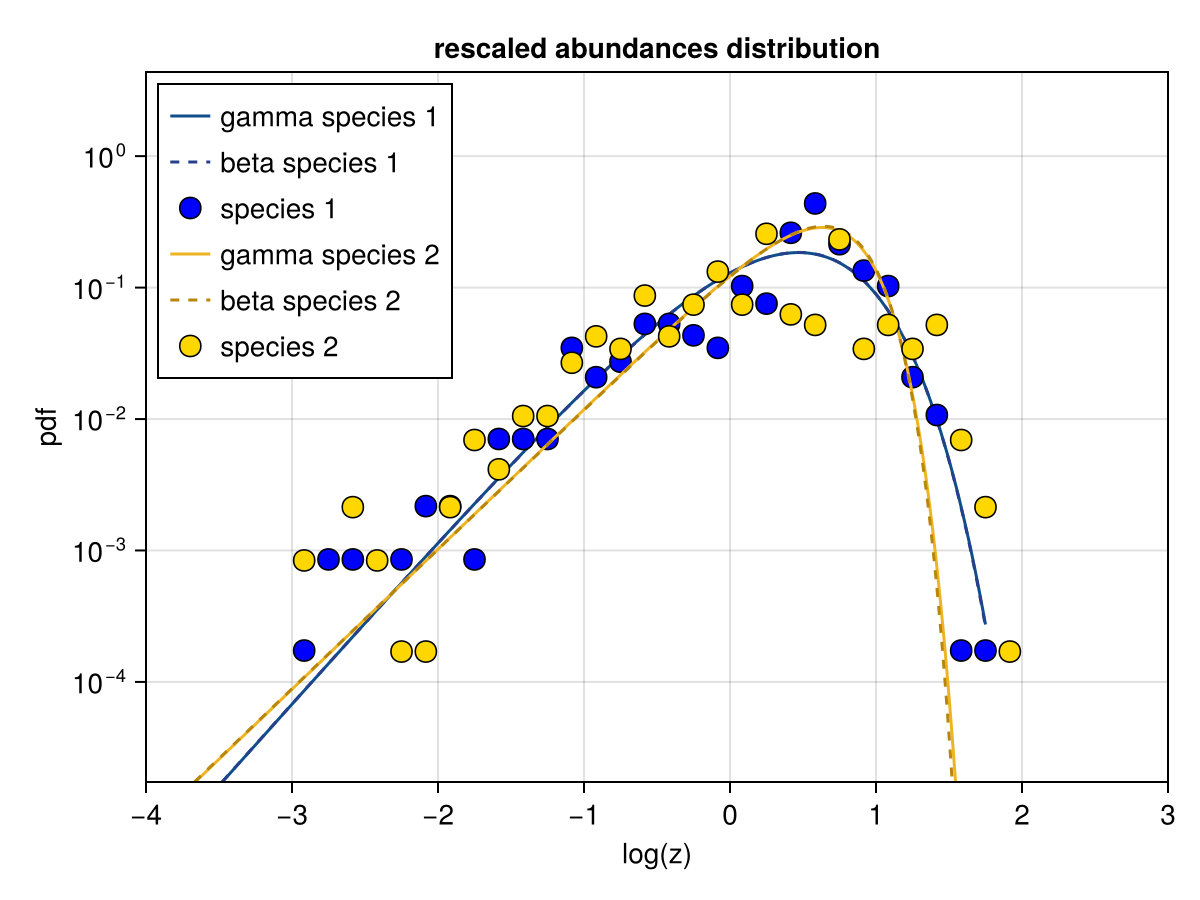

In [241]:
function lrg(z, α)
    return α*sqrt(trigamma(α)) .* z .+ α*digamma(α) .- exp.(z .* sqrt(trigamma(α)) .+ digamma(α)) .+ 0.5*log(trigamma(α)) .- loggamma(α)
end

function lrb(z, α, β)
    m = digamma(α) - digamma(α + β)
    s = sqrt(trigamma(α) - trigamma(α + β))
    c = loggamma(α + β) - loggamma(α) - loggamma(β)
    return c .+ α .* (z .* s .+ m) .+ (β - 1) .* log.(1 .- exp.(z .* s .+ m)) .+ log(s)
end

####### FIRST SPECIES #######
idx = 1

log_non_zero_data = [log.(x[x .> 0.0]) for x in eachcol(freqs)]
m = [mean(x) for x in log_non_zero_data]
s = [std(x) for x in log_non_zero_data]
log_non_zero_data = [(x .- m[i]) ./ s[i] for (i,x) in enumerate(log_non_zero_data)]
log_data = vcat(log_non_zero_data[idx]...)

# Compute normalized and recentered Histogram
bmin = round(minimum(log_data))
bmax = round(maximum(log_data))
Δb = (bmax - bmin) / 30
fh = FHist.Hist1D(log_data, binedges=bmin:Δb:bmax)

centers = bincenters(fh)
norm_counts = bincounts(fh) ./ (integral(fh) * Δb)

# Filter non-zero counts
valid = norm_counts .> 0.0
yy = 10 .^ log.(norm_counts[valid])
centers = centers[valid];

# Gamma params
α = stats[1] .^ 2 ./ stats[2]
α = α[idx]

# Beta params
γ = stats[1] ./ stats[2] .* (stats[1] .- stats[1] .^2 .- stats[2])
δ = γ .* (1 .- stats[1]) ./ stats[1]
γ = γ[idx]
δ = δ[idx]

# Plot
fig = Figure(figsize=(600,400))
ax  = Axis(fig[1, 1]; yscale=log10, limits=((bmin-1, bmax+1), (minimum(yy) / 10, maximum(yy) * 10)),
           xlabel = "log(z)", ylabel = "pdf", 
           title = "rescaled abundances distribution")

zrange = -5:0.01:maximum(centers)
gl = lines!(ax, zrange, 10 .^ lrg(zrange, α), color=:dodgerblue4, linewidth=1.5, label="gamma species $idx")
bl = lines!(ax, zrange, 10 .^ lrb(zrange, γ, δ), color=:royalblue4, linestyle=:dash, linewidth=1.5, label="beta species $idx")

sc = scatter!(ax, centers, yy, markersize=15,
            color = :blue,
            strokewidth = 0.8,
            strokecolor = :black,
            label="species $idx")

####### SECOND SPECIES #######
idx = 2

log_non_zero_data = [log.(x[x .> 0.0]) for x in eachcol(freqs)]
m = [mean(x) for x in log_non_zero_data]
s = [std(x) for x in log_non_zero_data]
log_non_zero_data = [(x .- m[i]) ./ s[i] for (i,x) in enumerate(log_non_zero_data)]
log_data = vcat(log_non_zero_data[idx]...)

# Compute normalized and recentered Histogram
bmin = round(minimum(log_data))
bmax = round(maximum(log_data))
Δb = (bmax - bmin) / 30
fh = FHist.Hist1D(log_data, binedges=bmin:Δb:bmax)

centers = bincenters(fh)
norm_counts = bincounts(fh) ./ (integral(fh) * Δb)

# Filter non-zero counts
valid = norm_counts .> 0.0
yy = 10 .^ log.(norm_counts[valid])
centers = centers[valid]

# Gamma params
α = stats[1] .^ 2 ./ stats[2]
α = α[idx]

# Beta params
γ = stats[1] ./ stats[2] .* (stats[1] .- stats[1] .^2 .- stats[2])
δ = γ .* (1 .- stats[1]) ./ stats[1]
γ = γ[idx]
δ = δ[idx]

# Plot
zrange = -5:0.01:maximum(centers)
gl = lines!(ax, zrange, 10 .^ lrg(zrange, α), color=:goldenrod2, linewidth=1.5, label="gamma species $idx")
bl = lines!(ax, zrange, 10 .^ lrb(zrange, γ, δ), color=:darkgoldenrod, linestyle=:dash, linewidth=1.5, label="beta species $idx")

sc = scatter!(ax, centers, yy, markersize=15,
            color = :gold,
            strokewidth = 0.8,
            strokecolor = :black,
            label="species $idx")

axislegend(ax; position = :lt)

fig